Tiny flip!!

In [1]:
from behave_analysis.database.Experiments.JAL007_ex import JAL7_30apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_tiny_3may, JAL8_21may

experiments_objects = [JAL8_tiny_3may, JAL8_21may, JAL7_30apr]

In [6]:
from behave_analysis.process.session import get_experiment 
from JR_test_scripts.tracking2features import tracking_to_features, extract_pa_across_sesh

import os
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
# fixed vars
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"Y:\Laurence"
save_path = r"Z:\Jasmine_Laurence\LDA_overview"
conditions = ['shelter_only','barrier_pre_flip','barrier_post_flip']
all_angles = ['hdir','hsa','h_preflipbar_a','h_postflipbar_a','h_rightbar_a','h_leftbar_a']
all_features = ['shelter','preflip_barrier','postflip_barrier','left_barrier', 'right_barrier', 'arena_bottom', 'arena_top']

settings = 'all_angles_fr_excl_prox_15cm'
# 'all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm'

In [14]:
# pulling out prediction accuracy for all sessions for a certain set of settings

sessy, all_names, avg_pa, pa = extract_pa_across_sesh(all_angles,experiments_objects, conditions, all_features, settings)

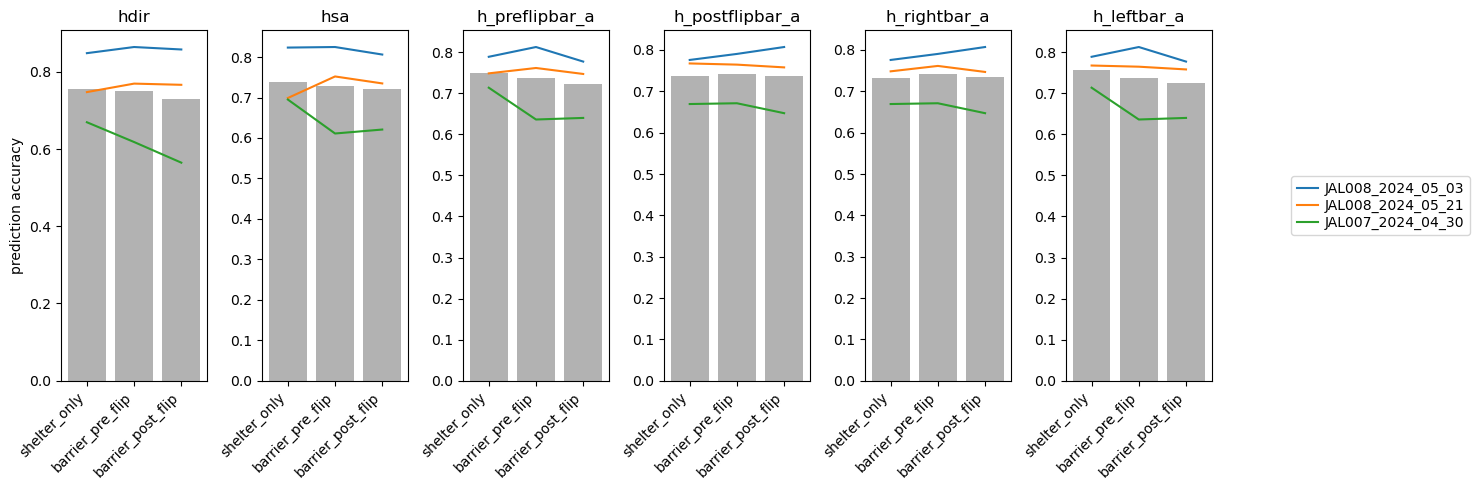

In [14]:
'''Plot the predicton accuracy for all sessions for the standard angles'''
fig, axs = plt.subplots(1,len(all_angles))
plt.rcParams['figure.figsize'] = [10, 5]
for idx, a in enumerate(all_angles):
    axs[idx].plot(conditions,pa[a].T)
    axs[idx].bar(conditions,np.mean(pa[a],axis=0),color = 'k',alpha = .3)
    axs[idx].set_title(a)
    axs[idx].set_xticks(np.arange(len(conditions)))
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
axs[idx].legend(all_names,
                loc='center left', 
                bbox_to_anchor=(1.5, .5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
axs[0].set_ylabel('prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('tiny_pa_allsesh_'+settings+'.png'))

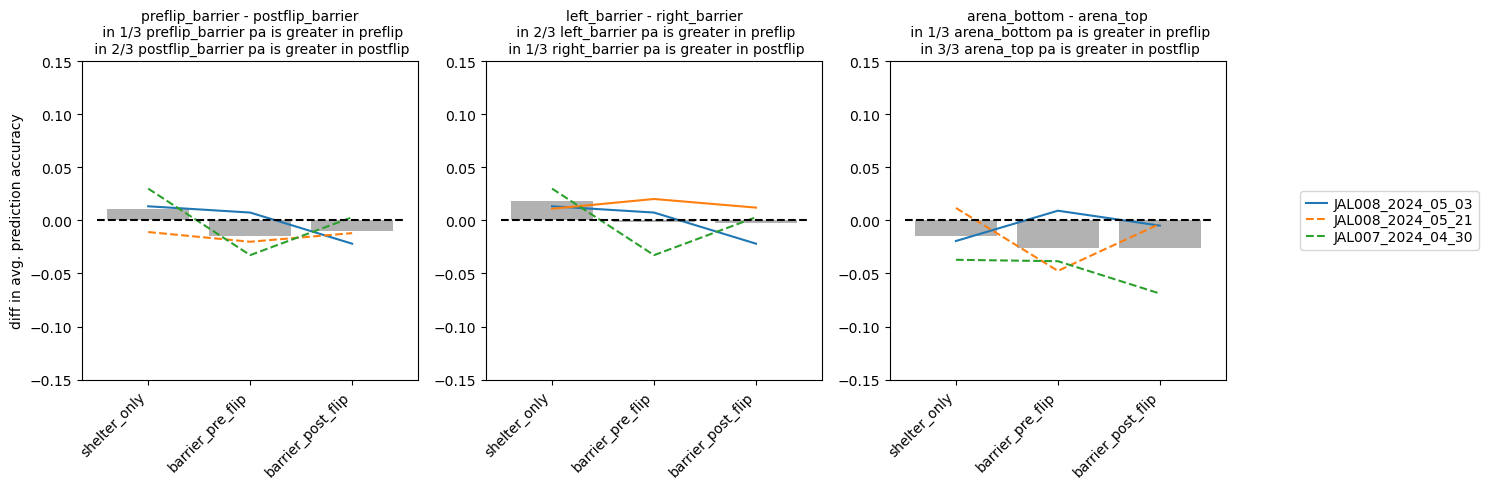

In [15]:
''' Plot the difference in pa (averaged over an area) for two goals'''
combos = [['preflip_barrier','postflip_barrier'],['left_barrier', 'right_barrier'], ['arena_bottom', 'arena_top']]

plt.rcParams['figure.figsize'] = [15, 5]
fig, axs = plt.subplots(1,len(combos))

for idx,c in enumerate(combos):
    diff = avg_pa[c[0]] - avg_pa[c[1]]
    axs[idx].bar(conditions,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
    for p in diff:
        if p[1] > 0: # p[2]:
            axs[idx].plot(conditions,p)
        else:
            axs[idx].plot(conditions,p,'--')
    axs[idx].plot([-.5,2.5],[0,0],'--k')
    axs[idx].set_title(c[0] + ' - ' + c[1]  +  
                       '\n in ' + str(np.sum(diff[:,1]>0)) + '/' + str(len(avg_pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip' +
                       '\n in ' + str(np.sum(diff[:,2]<0)) + '/' + str(len(avg_pa[c[0]])) + ' ' + c[1] + ' pa is greater in postflip',
                       fontsize = 10)
    axs[idx].set_xticks(np.arange(len(conditions)))
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
    axs[idx].set_ylim([-.15,.15])
axs[0].set_ylabel('diff in avg. prediction accuracy')
axs[idx].legend(all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.tight_layout()
plt.savefig(save_path+'/'+str('AVG_tiny_pa_diff_allsesh_'+settings+'.png'))

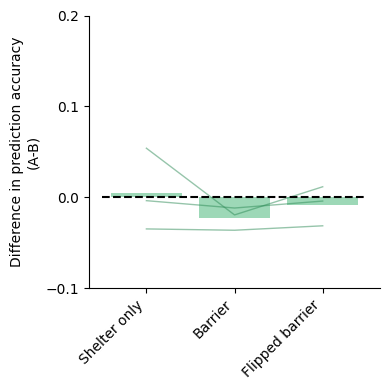

In [15]:
''' Plot the difference in pa for two goals'''
c = ['h_preflipbar_a','h_postflipbar_a']
cond = ['Shelter only','Barrier','Flipped barrier']

fig, axs = plt.subplots(1,1,figsize = (4,4))

diff = pa[c[0]] - pa[c[1]]
axs.bar(conditions,np.nanmean(diff,axis=0),color = 'mediumseagreen',alpha = .5)
for p in diff:
    axs.plot(conditions,p,color = 'seagreen',alpha = .5, linewidth = 1)
axs.plot([-.5,2.5],[0,0],'--k')
axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(cond,rotation = 45, ha="right")
axs.set_yticks([-.1,0,.1,.2])
axs.set_ylim([-.1,.2])
axs.set_ylabel('Difference in prediction accuracy\n(A-B)')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_tiny_diff_allsesh_'+settings+'.png'))